# K-Means Clustering — a step-by-step, runnable notebook

You are handed a pile of points with **no labels** and asked to find the natural groups. K-means makes one decisive bet — *a good cluster is a compact round blob around a centre* — and turns it into a loop any child could run: **drop k flags, send each point to its nearest flag, slide each flag to the middle of the points that gathered around it, repeat until nothing moves.** That loop is **Lloyd's algorithm**, and it provably lowers a single objective (the within-cluster sum of squares) at every step.

This notebook builds that, one measurement at a time, on **real scikit-learn data** (no download): **Wine** (178 wines, 13 chemical features, 3 cultivars), standardized, carries the load-bearing claims — the from-scratch/scikit-learn match, the init comparison, and the choice of *k*. A **controlled 2-D make_blobs** layout is used *only* to make Lloyd's iteration visible (you cannot watch centroids move in 13 dimensions), and **two moons + sheared blobs** show the honest failure modes. Every function used here lives in `kmeans.py`, imported so the notebook and the module can never drift apart.

By the end you will have **measured**, not just been told:

1. the **inertia** objective J, and that the mean is the **optimal** centre;
2. Lloyd's loop, with its inertia **falling monotonically** to convergence;
3. the from-scratch result **matching scikit-learn** on real Wine (same inertia, ARI = 1.0);
4. **k-means++** beating random seeding as a measured distribution;
5. **choosing k** by the elbow and the silhouette (both pick k=3 on Wine);
6. the **failure modes** — moons and anisotropic blobs — quantified by a low ARI.

Everything runs on CPU in a couple of seconds, seeded for reproducibility.

## Step 0 — Setup and version banner

We import the real functions from the chapter module (so this notebook uses the *exact same code* the figures and the page use) and print the library versions the results were produced on.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sklearn

from kmeans import (
    assign, inertia, kpp_init, lloyd_history, KMeansScratch,
    verify_against_sklearn, compare_init, sweep_k, measure_failure,
    load_wine_scaled, load_blobs_2d, load_blobs_many, load_moons, load_anisotropic,
    WINE_K, MANY_K,
)

print(f'numpy {np.__version__} | scikit-learn {sklearn.__version__}')
wine = load_wine_scaled()
blobs = load_blobs_2d()
print(f'Wine : {wine.x.shape[0]} wines x {wine.x.shape[1]} standardized features, '
      f'true k = {wine.true_k}')
print(f'Blobs: {blobs.x.shape[0]} 2-D points, {blobs.true_k} controlled clusters (for the animation)')

numpy 2.4.6 | scikit-learn 1.9.0
Wine : 178 wines x 13 standardized features, true k = 3
Blobs: 500 2-D points, 4 controlled clusters (for the animation)


## Step 1 — The objective: inertia (within-cluster sum of squares)

K-means minimizes one number — the **inertia**, the total squared distance from each point to its cluster's centre:

$$J = \sum_{i=1}^{n} \lVert x_i - \mu_{c_i} \rVert^2$$

Small $J$ means tight, compact clusters. Let's compute it for a tiny hand-checkable case: four points in two obvious pairs, with the centres at the pair midpoints.

In [2]:
X = np.array([[0.0, 0.0], [0.0, 1.0], [8.0, 8.0], [9.0, 8.0]])
centers = np.array([[0.0, 0.5], [8.5, 8.0]])   # midpoints of the two pairs
labels = np.array([0, 0, 1, 1])
print(f'inertia J = {inertia(X, labels, centers):.2f}')
# by hand: left pair each 0.5 from (0,0.5) -> 0.25+0.25; right pair each 0.5 from (8.5,8) -> 0.25+0.25
print('by hand   = 0.25 + 0.25 + 0.25 + 0.25 = 1.00  (matches)')

inertia J = 1.00
by hand   = 0.25 + 0.25 + 0.25 + 0.25 = 1.00  (matches)


## Step 2 — The assign step (E-step): each point to its nearest centroid

With the centres fixed, the **best** label for a point is trivially its nearest centre — that is the assignment that minimizes its term in $J$. `assign` computes the full point-to-centre squared-distance matrix and takes the `argmin`.

In [3]:
seed_centers = kpp_init(blobs.x, blobs.true_k, np.random.default_rng(0))
lab = assign(blobs.x, seed_centers)
print(f'{blobs.x.shape[0]} points assigned to {blobs.true_k} centroids')
print(f'cluster sizes: {np.bincount(lab)}')
print('each point now belongs to whichever centroid is closest — a Voronoi partition.')

500 points assigned to 4 centroids
cluster sizes: [125 125 125 125]
each point now belongs to whichever centroid is closest — a Voronoi partition.


## Step 3 — The update step (M-step): the mean is the optimal centre

With the labels fixed, what is the best centre for a cluster? Minimize $\sum_{i} \lVert x_i - \mu \rVert^2$: set the gradient to zero, $\sum_i -2(x_i - \mu) = 0$, and out falls $\mu = \frac{1}{|C|}\sum_i x_i$ — the **arithmetic mean**. So 'move each centroid to the mean of its members' is not a heuristic; it is provably optimal. Let's confirm the mean beats any nudge away from it.

In [4]:
cluster = blobs.x[lab == 0]
mu = cluster.mean(axis=0)
def sse(c):
    return float(((cluster - c) ** 2).sum())
print(f'SSE at the mean {np.round(mu, 3)} : {sse(mu):.2f}')
for nudge in ([0.5, 0.0], [0.0, 0.5], [-0.5, -0.5]):
    print(f'SSE at mean + {nudge} : {sse(mu + np.array(nudge)):.2f}  (higher)')
print('\nAny move away from the mean raises the within-cluster SSE — the mean is the minimizer.')

SSE at the mean [-2.602  9.092] : 237.97
SSE at mean + [0.5, 0.0] : 269.22  (higher)
SSE at mean + [0.0, 0.5] : 269.22  (higher)
SSE at mean + [-0.5, -0.5] : 300.47  (higher)

Any move away from the mean raises the within-cluster SSE — the mean is the minimizer.


## Step 4 — k-means++ seeding: spread the seeds with D² sampling

A bad random init can strand two seeds in one blob and leave another unseeded — a local optimum Lloyd's cannot escape. **k-means++** picks the first centre at random, then each next centre with probability proportional to $D(x)^2$ (squared distance to the nearest chosen centre) — biasing hard toward far-apart seeds while staying randomized. Here are four seeds it places on the blobs.

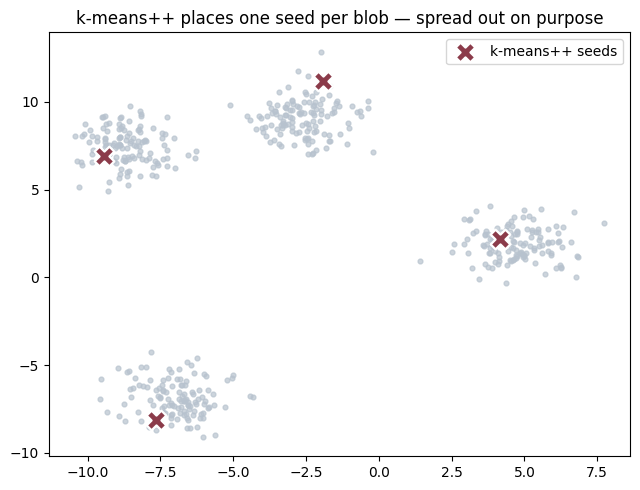

Each of the four blobs gets a seed: k-means++ avoids the clumped starts random init suffers.


In [5]:
seeds = kpp_init(blobs.x, blobs.true_k, np.random.default_rng(1))
plt.figure(figsize=(6.5, 5))
plt.scatter(blobs.x[:, 0], blobs.x[:, 1], s=12, color='#B7C2CE', alpha=0.7)
plt.scatter(seeds[:, 0], seeds[:, 1], marker='X', s=200, color='#8B3B4A',
            edgecolor='white', linewidth=1.6, label='k-means++ seeds')
plt.title('k-means++ places one seed per blob — spread out on purpose')
plt.legend()
plt.tight_layout()
plt.show()
print('Each of the four blobs gets a seed: k-means++ avoids the clumped starts random init suffers.')

## Step 5 — Lloyd's algorithm and the monotone-decreasing inertia

Alternate the two steps until the assignments stop changing. **Neither step can raise $J$** (assign picks the nearest centre; update picks the optimal mean), so $J$ falls monotonically — and since it is bounded below by 0 with finitely many possible assignments, the loop **must converge**. `lloyd_history` records $J$ at every iteration; watch it fall from a deliberately poor random start.

In [6]:
history = lloyd_history(blobs.x, blobs.true_k, seed=7, init='random')
js = [s.inertia for s in history]
for it, j in enumerate(js):
    print(f'  iter {it}: J = {j:9.1f}')
assert all(js[i + 1] <= js[i] + 1e-9 for i in range(len(js) - 1)), 'J must never rise'
print(f'\nconverged in {len(js) - 1} steps; J fell {js[0]:.0f} -> {js[-1]:.0f}, never rising.')

  iter 0: J =   25329.0
  iter 1: J =   15020.0
  iter 2: J =   14316.3
  iter 3: J =   14216.2
  iter 4: J =   12693.5
  iter 5: J =    2161.0
  iter 6: J =     948.9

converged in 6 steps; J fell 25329 -> 949, never rising.


## Step 6 — See it converge: centroids migrating

The same run, drawn. The X centroids start poorly placed (two share the top blob), sit on a plateau, then one **breaks through** to the empty blob and the inertia plunges. This is the whole algorithm in one picture.

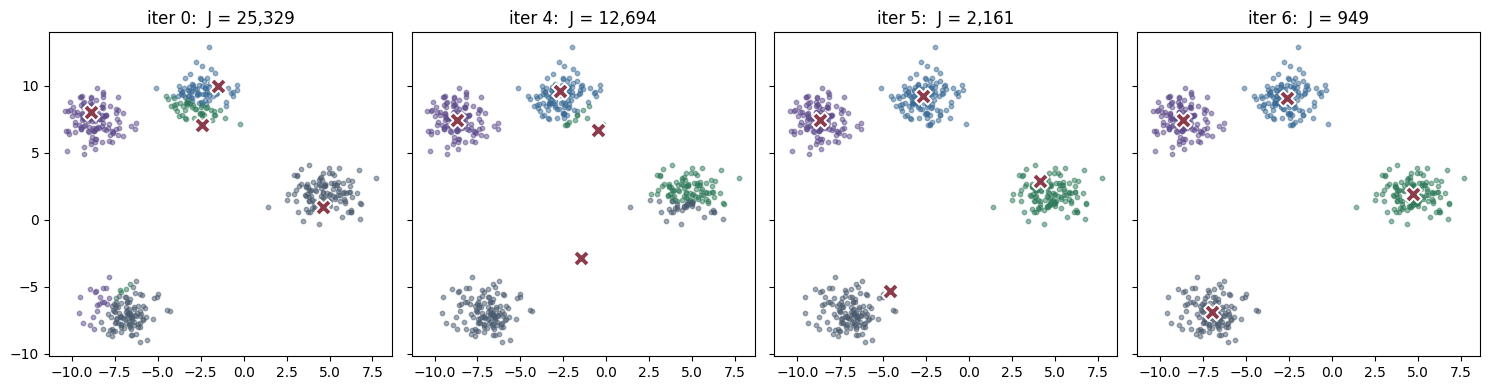

In [7]:
panels = [0, 4, 5, len(history) - 1]
colours = ['#3A6B96', '#5D4A8A', '#2E7A5A', '#4A5B6E']
fig, axes = plt.subplots(1, 4, figsize=(15, 4), sharex=True, sharey=True)
for ax, it in zip(axes, panels):
    snap = history[it]
    for c in range(blobs.true_k):
        m = snap.labels == c
        ax.scatter(blobs.x[m, 0], blobs.x[m, 1], s=10, color=colours[c], alpha=0.5)
    ax.scatter(snap.centers[:, 0], snap.centers[:, 1], marker='X', s=140,
               color='#8B3B4A', edgecolor='white', linewidth=1.4)
    ax.set_title(f'iter {it}:  J = {snap.inertia:,.0f}')
plt.tight_layout()
plt.show()

## Step 7 — What k-means computes: a Voronoi partition of convex cells

The assign step sends each point to its nearest centroid, so the boundary between two clusters is the set of points **equidistant** from their centres — a straight line (in 2-D) or hyperplane. The result is a **Voronoi diagram**: $k$ convex polygonal cells, one per centroid, with flat boundaries. Fit our `KMeansScratch` on the blobs and paint its prediction over a dense grid — the straight cell walls are the whole reason k-means cannot bend around curved structure (Steps 10–11).

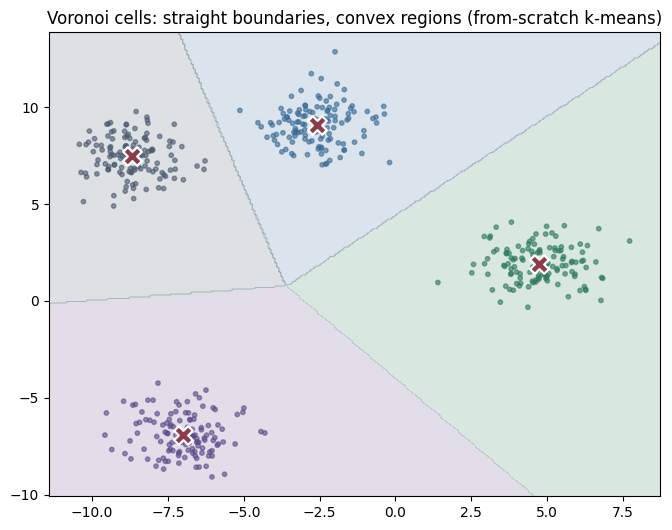

final inertia = 948.9  |  2 iterations to converge
Every boundary is a straight line — k-means can only carve CONVEX cells.


In [8]:
km = KMeansScratch(n_clusters=blobs.true_k, init='k-means++', n_init=10, seed=0).fit(blobs.x)
x0 = np.linspace(blobs.x[:, 0].min() - 1, blobs.x[:, 0].max() + 1, 300)
x1 = np.linspace(blobs.x[:, 1].min() - 1, blobs.x[:, 1].max() + 1, 300)
gx, gy = np.meshgrid(x0, x1)
regions = assign(np.column_stack([gx.ravel(), gy.ravel()]), km.cluster_centers_).reshape(gx.shape)
colours = ['#3A6B96', '#5D4A8A', '#2E7A5A', '#4A5B6E']
plt.figure(figsize=(6.8, 5.4))
plt.contourf(gx, gy, regions, alpha=0.18, levels=[-0.5, 0.5, 1.5, 2.5, 3.5], colors=colours)
plt.scatter(blobs.x[:, 0], blobs.x[:, 1], s=10, c=[colours[c] for c in km.labels_], alpha=0.6)
plt.scatter(km.cluster_centers_[:, 0], km.cluster_centers_[:, 1], marker='X', s=180,
            color='#8B3B4A', edgecolor='white', linewidth=1.6)
plt.title('Voronoi cells: straight boundaries, convex regions (from-scratch k-means)')
plt.tight_layout()
plt.show()
print(f'final inertia = {km.inertia_:.1f}  |  {km.n_iter_} iterations to converge')
print('Every boundary is a straight line — k-means can only carve CONVEX cells.')

## Step 8 — Is it the real thing? Verify against scikit-learn on real Wine

Now the real dataset. Cluster standardized **Wine** with our `KMeansScratch` and scikit-learn's `KMeans` (same k, n_init, seed). Because **cluster labels are arbitrary** (our 'cluster 0' need not be sklearn's 'cluster 0'), we do not compare labels directly — we compare the **inertia** (the objective value) and the **adjusted Rand index** (agreement up to a permutation). A match on both is the honest proof our Lloyd's is genuine.

In [9]:
match = verify_against_sklearn(wine, k=WINE_K)
print(f'from-scratch inertia : {match.scratch_inertia:.3f}')
print(f'scikit-learn inertia : {match.sklearn_inertia:.3f}')
print(f'adjusted Rand index  : {match.ari:.3f}   (1.0 = identical partition up to a permutation)')
assert abs(match.scratch_inertia - match.sklearn_inertia) < 1.0
assert match.ari > 0.99
print('\n=> same inertia, same partition: the from-scratch algorithm is the real thing.')

from-scratch inertia : 1277.928
scikit-learn inertia : 1277.928
adjusted Rand index  : 1.000   (1.0 = identical partition up to a permutation)

=> same inertia, same partition: the from-scratch algorithm is the real thing.


## Step 9 — k-means++ vs random, as a measured distribution

Initialization barely matters on cleanly-separated data (random almost always finds Wine's 3 clusters), but its cost grows with the number of clusters. On a controlled **12-blob** layout, run 50 single starts each way and histogram the final inertia: random scatters with a heavy bad-local-optimum tail, k-means++ piles near the global optimum.

random    : mean 5010  std 465  best 4493  worst 7025
k-means++ : mean 4722  std 185  best 4493  worst 5145


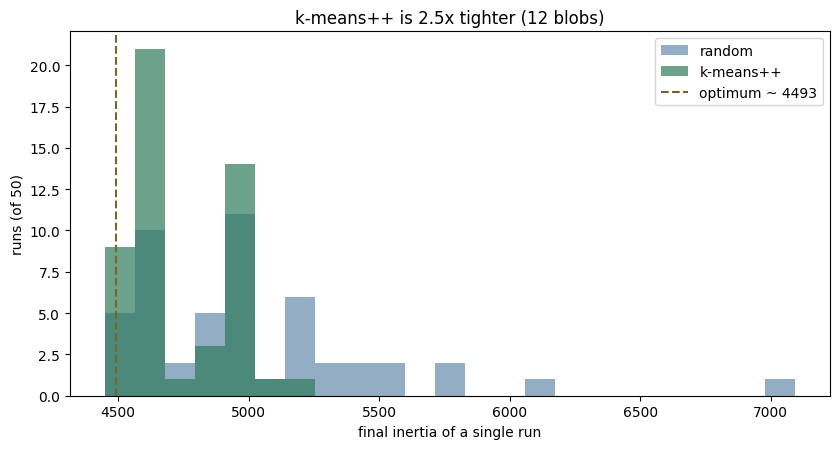

In [10]:
comp = compare_init(load_blobs_many(), k=MANY_K)
r = comp.summary('random')
p = comp.summary('kpp')
print(f"random    : mean {r['mean']:.0f}  std {r['std']:.0f}  best {r['best']:.0f}  worst {r['worst']:.0f}")
print(f"k-means++ : mean {p['mean']:.0f}  std {p['std']:.0f}  best {p['best']:.0f}  worst {p['worst']:.0f}")
bins = np.linspace(comp.kpp_inertias.min() * 0.99, comp.random_inertias.max() * 1.01, 24)
plt.figure(figsize=(8.5, 4.6))
plt.hist(comp.random_inertias, bins=bins, color='#3A6B96', alpha=0.55, label='random')
plt.hist(comp.kpp_inertias, bins=bins, color='#2E7A5A', alpha=0.7, label='k-means++')
plt.axvline(p['best'], color='#7A6528', ls='--', label=f"optimum ~ {p['best']:.0f}")
plt.xlabel('final inertia of a single run')
plt.ylabel('runs (of 50)')
plt.title(f"k-means++ is {r['std']/p['std']:.1f}x tighter (12 blobs)")
plt.legend()
plt.tight_layout()
plt.show()

## Step 10 — Choosing k on real Wine: elbow + silhouette

K needs to be chosen. Inertia **always** falls as k grows, so you can only read its **bend** (the elbow). The **silhouette** — for each point, (nearest-other-cluster distance − own-cluster distance) / max — has a genuine **peak**. Sweep k on Wine: both point to k=3, the true number of cultivars — and because we happen to know Wine's real labels, we can confirm the k=3 clustering matches them at an adjusted Rand index of ~0.90.

  k    inertia   silhouette
  2     1658.8        0.259
  3     1277.9        0.285  <- peak
  4     1175.4        0.260
  5     1109.5        0.202
  6     1046.0        0.237
  7      981.6        0.204


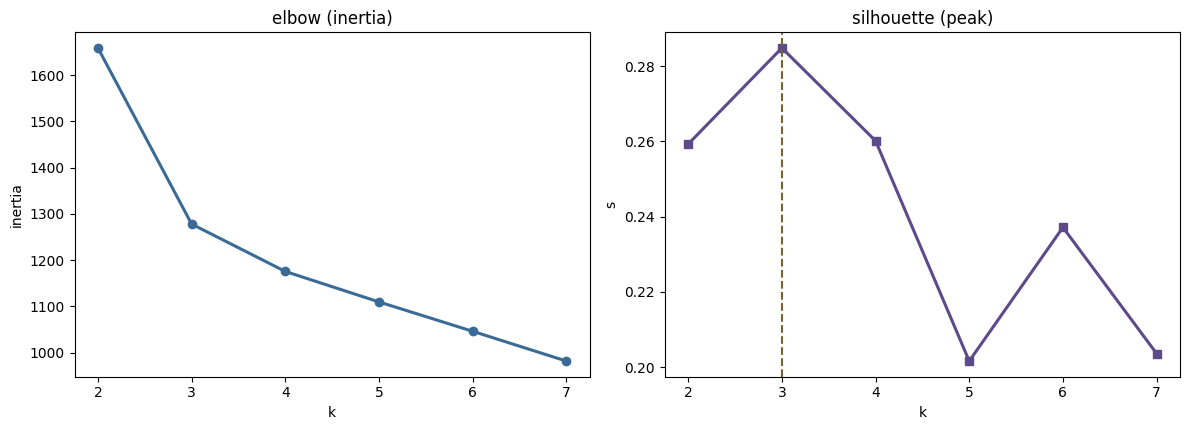


silhouette peaks at k=3 — the true number of Wine cultivars.
adjusted Rand index at k=3 vs the true cultivars: 0.897 (unsupervised, yet close to the labels)


In [11]:
sweep = sweep_k(wine)
print(f'{"k":>3}{"inertia":>11}{"silhouette":>13}')
for k, jj, ss in zip(sweep.ks, sweep.inertias, sweep.silhouettes):
    mark = '  <- peak' if k == sweep.best_k_silhouette else ''
    print(f'{k:>3}{jj:>11.1f}{ss:>13.3f}{mark}')
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4.4))
a1.plot(sweep.ks, sweep.inertias, 'o-', color='#3A6B96', lw=2.2)
a1.set_title('elbow (inertia)')
a1.set_xlabel('k')
a1.set_ylabel('inertia')
a2.plot(sweep.ks, sweep.silhouettes, 's-', color='#5D4A8A', lw=2.2)
a2.set_title('silhouette (peak)')
a2.axvline(sweep.best_k_silhouette, color='#7A6528', ls='--')
a2.set_xlabel('k')
a2.set_ylabel('s')
plt.tight_layout()
plt.show()
print(f'\nsilhouette peaks at k={sweep.best_k_silhouette} — the true number of Wine cultivars.')
# We happen to know Wine's true cultivar labels, so we can score the k=3 clustering against them.
recovery = measure_failure(wine, k=3)   # ARI of the sklearn k=3 partition vs the real labels
print(f'adjusted Rand index at k=3 vs the true cultivars: {recovery.ari:.3f} '
      '(unsupervised, yet close to the labels)')

## Step 11 — Where it breaks (1): non-convex moons

K-means draws **straight** (Voronoi) boundaries, so it cannot represent a crescent. On two interleaving moons the true clusters are the two arcs, but k-means slices a line straight through both. The adjusted Rand index against the true labels quantifies the failure (≈ 0 = chance, 1 = perfect).

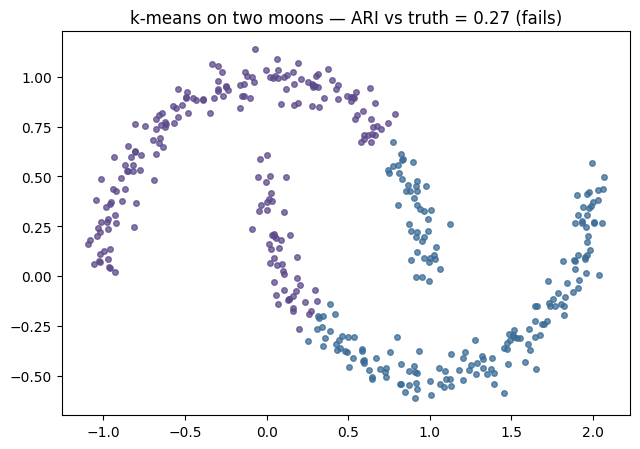

ARI = 0.274: k-means split each moon in half instead of separating the two arcs.


In [12]:
moons = load_moons()
fail = measure_failure(moons, k=2)
plt.figure(figsize=(6.5, 4.6))
for c in range(2):
    m = fail.labels == c
    plt.scatter(moons.x[m, 0], moons.x[m, 1], s=16, color=['#3A6B96', '#5D4A8A'][c], alpha=0.75)
plt.title(f'k-means on two moons — ARI vs truth = {fail.ari:.2f} (fails)')
plt.tight_layout()
plt.show()
assert fail.ari < 0.5
print(f'ARI = {fail.ari:.3f}: k-means split each moon in half instead of separating the two arcs.')

## Step 12 — Where it breaks (2): anisotropic (sheared) blobs

Squared Euclidean distance treats every direction equally, so k-means expects **round** clusters. Three diagonally-stretched blobs have orientation the algorithm ignores — its round Voronoi cells cut across the stripes. Again, ARI measures the damage.

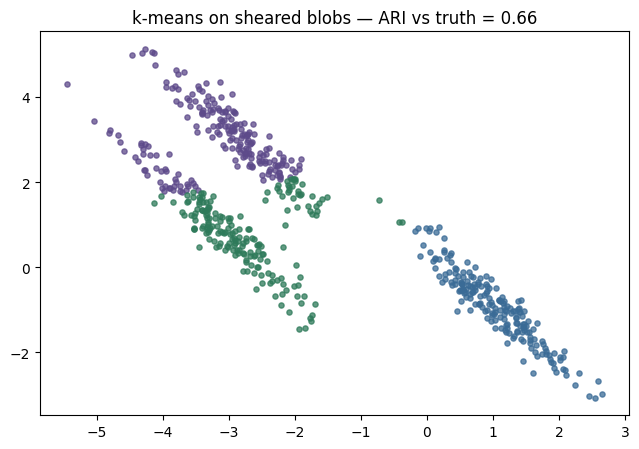

ARI = 0.659: better than the moons, but the round cells still cut across the stripes.
A Gaussian Mixture Model, which gives each cluster its own covariance, recovers these.


In [13]:
aniso = load_anisotropic()
fail_a = measure_failure(aniso, k=3)
plt.figure(figsize=(6.5, 4.6))
for c in range(3):
    m = fail_a.labels == c
    plt.scatter(aniso.x[m, 0], aniso.x[m, 1], s=14,
                color=['#3A6B96', '#5D4A8A', '#2E7A5A'][c], alpha=0.75)
plt.title(f'k-means on sheared blobs — ARI vs truth = {fail_a.ari:.2f}')
plt.tight_layout()
plt.show()
print(f'ARI = {fail_a.ari:.3f}: better than the moons, but the round cells still cut across the stripes.')
print('A Gaussian Mixture Model, which gives each cluster its own covariance, recovers these.')

## Recap

On real scikit-learn data (plus clearly-labelled controlled illustrations), one runnable notebook built the whole of k-means:

| Step | What we measured | The takeaway |
|---|---|---|
| 1–3 | inertia; assign; update | J = Σ‖x−μ‖²; nearest-centre labels; the **mean** is the optimal centre |
| 4–6 | k-means++; Lloyd's; the animation | spread seeds ∝ D²; **J falls monotonically** to convergence |
| 7 | the Voronoi partition | straight boundaries, **convex** cells — the source of every failure mode |
| 8 | verify vs scikit-learn (Wine) | **same inertia, ARI = 1.0** — the from-scratch loop is genuine |
| 9 | k-means++ vs random (12 blobs) | k-means++ is **~2.5× tighter**; the advantage grows with k |
| 10 | choosing k (Wine) | inertia **bends**, silhouette **peaks** — both at the true k=3 |
| 11–12 | moons; anisotropic blobs | **low ARI** — straight cuts fail curved/sheared structure |

**K-means partitions points by minimizing the within-cluster sum of squares; Lloyd's algorithm alternates assign and update, each step provably lowering J, so it converges — to a *local* optimum (the global one is NP-hard), which k-means++ and restarts make a good one.** It assumes spherical, equal-size clusters — exactly the hard limit of a Gaussian mixture, and the reason the next chapters reach for **DBSCAN**, **GMMs**, and **spectral clustering**.